<a href="https://colab.research.google.com/github/rakeshbanisetti/mds_lab/blob/main/empirical_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install datasets

In [2]:
from datasets import load_dataset

# Loading the dataset provided by the user
dataset_name = 'sanadf234/Heart-Disease-Prediction-dataset'
dataset = load_dataset(dataset_name)

# Display the dataset structure
print(dataset)

README.md:   0%|          | 0.00/31.0 [00:00<?, ?B/s]

heart_disease_prediction.csv:   0%|          | 0.00/5.17M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/54897 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'age', 'gender', 'chest_pain_type', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'slope', 'thal', 'heart_disease'],
        num_rows: 54897
    })
})


In [3]:
# Display a sample from the training set
if 'train' in dataset:
    df = dataset['train'].to_pandas()
    display(df.head())
else:
    # If there are no standard splits, display from the first available split
    first_key = list(dataset.keys())[0]
    df = dataset[first_key].to_pandas()
    display(df.head())

,id,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,slope,thal,heart_disease
0,1,77,Female,Non-Anginal Pain,120,542,0,Left Ventricular Hypertrophy,185,No,3.9,Upsloping,Reversible Defect,1
1,2,51,Female,Asymptomatic,192,423,1,ST-T Wave Abnormality,78,No,6.3,Flat,Fixed Defect,1
2,3,79,Female,Atypical Angina,182,557,1,ST-T Wave Abnormality,111,No,4.7,Flat,Normal,1
3,4,74,Male,Typical Angina,102,159,1,Normal,147,No,5.1,Flat,Normal,1
4,5,54,Male,Non-Anginal Pain,183,278,0,ST-T Wave Abnormality,195,Yes,4.3,Upsloping,Normal,1


In [4]:
import numpy as np
import pandas as pd

# Create a copy of the original dataset to generate synthetic data
synthetic_df = df.copy()

# Identify numerical features where measures should be varied within +/- 15%
numerical_cols = ['age', 'resting_bp', 'cholesterol', 'max_heart_rate', 'oldpeak']

for col in numerical_cols:
    if col in synthetic_df.columns:
        # Ensure the column is numeric
        synthetic_df[col] = pd.to_numeric(synthetic_df[col], errors='coerce')

        # Generate a random factor between -15% (-0.15) and +15% (+0.15) for each row
        random_factor = np.random.uniform(-0.15, 0.15, size=len(synthetic_df))

        # Apply the variation
        synthetic_df[col] = synthetic_df[col] * (1 + random_factor)

        # Round integer metrics appropriately
        if col in ['age', 'resting_bp', 'cholesterol', 'max_heart_rate']:
            synthetic_df[col] = synthetic_df[col].round().astype(int)
        else:
            synthetic_df[col] = synthetic_df[col].round(2)

# Compare a few rows of original and synthetic datasets
print("Original Dataset:")
display(df[numerical_cols].head())

print("\nSynthetic Dataset (With <= 15% change in measures):")
display(synthetic_df[numerical_cols].head())

Original Dataset:


,age,resting_bp,cholesterol,max_heart_rate,oldpeak
0,77,120,542,185,3.9
1,51,192,423,78,6.3
2,79,182,557,111,4.7
3,74,102,159,147,5.1
4,54,183,278,195,4.3



Synthetic Dataset (With <= 15% change in measures):


,age,resting_bp,cholesterol,max_heart_rate,oldpeak
0,68,134,567,158,4.22
1,50,178,379,74,6.06
2,86,185,605,102,5.33
3,85,106,159,163,4.88
4,50,178,283,207,4.46


,Original Age,Synthetic Age
count,54897.000000,54897.000000
mean,53.987012,53.985555
std,21.100459,21.691249
min,18.000000,15.000000
25%,36.000000,35.000000
50%,54.000000,54.000000
75%,72.000000,72.000000
max,90.000000,103.000000


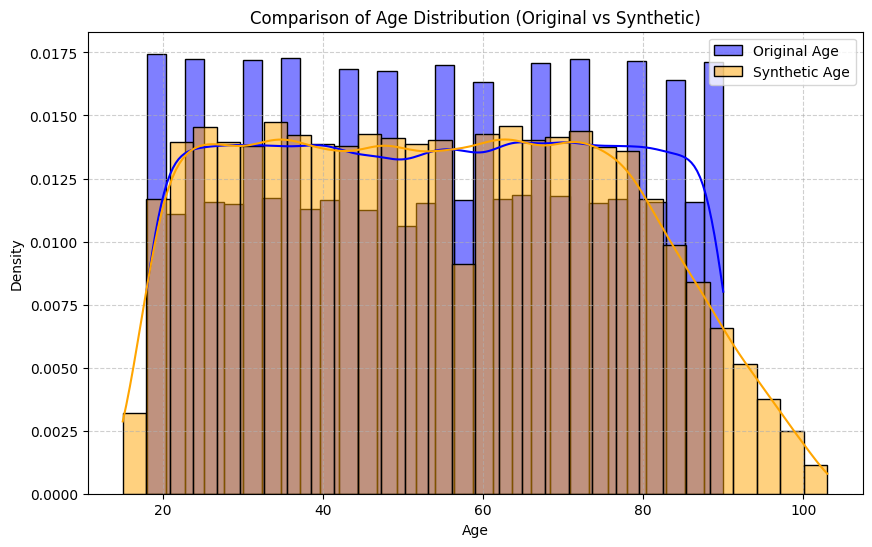

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate descriptive statistics
age_comparison = pd.DataFrame({
    'Original Age': df['age'].describe(),
    'Synthetic Age': synthetic_df['age'].describe()
})
display(age_comparison)

# Plot overlapping histograms and KDEs
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], color='blue', label='Original Age', kde=True, stat='density', alpha=0.5, bins=30)
sns.histplot(synthetic_df['age'], color='orange', label='Synthetic Age', kde=True, stat='density', alpha=0.5, bins=30)
plt.title("Comparison of Age Distribution (Original vs Synthetic)")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define our features (X) and target (y)
X = df.drop(columns=['id', 'heart_disease'])
y = df['heart_disease']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

# Create a preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Combine preprocessing with the classifier
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1))
])

# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predict on the test set
y_pred = model_pipeline.predict(X_test)

# Print evaluation metrics
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.9998

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2322
           1       1.00      1.00      1.00      8658

    accuracy                           1.00     10980
   macro avg       1.00      1.00      1.00     10980
weighted avg       1.00      1.00      1.00     10980



In [7]:
# Prepare the features and target from the synthetic dataset
X_synth = synthetic_df.drop(columns=['id', 'heart_disease'])
y_synth = synthetic_df['heart_disease']

# Use our trained pipeline to make predictions on the synthetic dataset
y_pred_synth = model_pipeline.predict(X_synth)

# Evaluate the model's performance on synthetic data
print(f"Accuracy on Synthetic Dataset: {accuracy_score(y_synth, y_pred_synth):.4f}\n")
print("Classification Report on Synthetic Dataset:")
print(classification_report(y_synth, y_pred_synth))

Accuracy on Synthetic Dataset: 0.9527

Classification Report on Synthetic Dataset:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     11611
           1       0.97      0.97      0.97     43286

    accuracy                           0.95     54897
   macro avg       0.93      0.93      0.93     54897
weighted avg       0.95      0.95      0.95     54897

